# Task 5 — Strategy Backtesting

**Portfolio Optimization Challenge (Week 9)** · Strategy vs. Benchmark on out-of-sample data

> **Objective.** A forecast and an optimized portfolio are *hypotheses*; a backtest is the experiment
> that validates them. We simulate the Task 4 recommended portfolio over the **out-of-sample holdout**
> and compare it against a simple passive **60/40 SPY/BND** benchmark to judge whether the model-driven
> approach would actually have paid off.

**Setup**
- **Backtest window:** 2025-01-01 → 2026-06-30 — the full holdout, **not used to train any model**.
- **Strategy (from Task 4):** the recommended **Max-Sharpe** portfolio → **100% SPY**. We also track the
  **Min-Volatility** portfolio (≈95% BND / 5% SPY) as a conservative variant.
- **Benchmark:** static **60% SPY / 40% BND**.
- **Simulation:** both **buy-and-hold** (drift) and **monthly rebalancing** to target weights.


## 1 · Setup, data & portfolio definitions

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (13, 6)
plt.rcParams["axes.titleweight"] = "bold"

RF = 0.02              # annual risk-free rate (consistent with Tasks 1 & 4)
TRADING_DAYS = 252
ASSETS = ["TSLA", "SPY", "BND"]
START, END = "2025-01-01", "2026-06-30"

wide = pd.read_csv("../data/processed/adj_close.csv", parse_dates=["Date"], index_col="Date")[ASSETS]
bt_prices = wide.loc[START:END]
daily = bt_prices.pct_change().dropna()
print(f"Backtest window: {daily.index.min().date()} → {daily.index.max().date()} "
      f"({len(daily)} trading days)")

# Portfolio weights (strategy weights come from Task 4's optimization).
PORTFOLIOS = {
    "Strategy — Max-Sharpe (100% SPY)":  {"TSLA": 0.0,  "SPY": 1.00,  "BND": 0.00},
    "Min-Volatility (95% BND / 5% SPY)": {"TSLA": 0.0,  "SPY": 0.055, "BND": 0.945},
    "Benchmark — 60/40 SPY/BND":         {"TSLA": 0.0,  "SPY": 0.60,  "BND": 0.40},
}
pd.DataFrame(PORTFOLIOS).T[ASSETS]

Backtest window: 2025-01-03 → 2026-06-30 (372 trading days)


,TSLA,SPY,BND
Strategy — Max-Sharpe (100% SPY),0.0,1.000,0.000
Min-Volatility (95% BND / 5% SPY),0.0,0.055,0.945
Benchmark — 60/40 SPY/BND,0.0,0.600,0.400


## 2 · Backtesting engine

We invest \$1 split by the target weights and roll forward day by day. In **buy-and-hold** mode weights
drift with returns; in **monthly-rebalance** mode we reset to target weights at the start of each new
month. The function returns the portfolio value path (growth of \$1).

In [2]:
def simulate(daily_rets, weights, rebalance="M"):
    cols = daily_rets.columns
    w = np.array([weights.get(c, 0.0) for c in cols], float)
    asset_val = w.copy()                       # $1 split by target weights
    idx = daily_rets.index
    vals = [1.0]                               # value on the day BEFORE the window
    for i in range(len(idx)):
        asset_val = asset_val * (1 + daily_rets.iloc[i].values)
        vals.append(asset_val.sum())
        if rebalance == "M" and i + 1 < len(idx) and idx[i + 1].month != idx[i].month:
            asset_val = asset_val.sum() * w    # rebalance to target at month boundary
    return pd.Series(vals, index=[idx[0] - pd.Timedelta(days=1)] + list(idx), name="value")


def performance(value, rf=RF):
    r = value.pct_change().dropna()
    total = value.iloc[-1] / value.iloc[0] - 1
    ann = (value.iloc[-1] / value.iloc[0]) ** (TRADING_DAYS / len(r)) - 1
    vol = r.std() * np.sqrt(TRADING_DAYS)
    sharpe = (ann - rf) / vol
    drawdown = value / value.cummax() - 1
    return {"Total return %": total * 100, "Annualized %": ann * 100,
            "Volatility %": vol * 100, "Sharpe": sharpe, "Max drawdown %": drawdown.min() * 100}, drawdown

print("Engine ready.")

Engine ready.


## 3 · Run the backtest (monthly rebalancing)

In [3]:
curves, dd_curves, rows = {}, {}, []
for name, w in PORTFOLIOS.items():
    val = simulate(daily, w, rebalance="M")
    perf, dd = performance(val)
    curves[name] = val
    dd_curves[name] = dd
    rows.append(pd.Series(perf, name=name))

metrics = pd.DataFrame(rows).round(2)
metrics

,Total return %,Annualized %,Volatility %,Sharpe,Max drawdown %
Strategy — Max-Sharpe (100% SPY),29.92,19.40,17.92,0.97,-18.76
Min-Volatility (95% BND / 5% SPY),8.68,5.80,4.37,0.87,-2.71
Benchmark — 60/40 SPY/BND,20.81,13.66,11.05,1.06,-11.25


## 4 · Cumulative Returns — Strategy vs. Benchmark

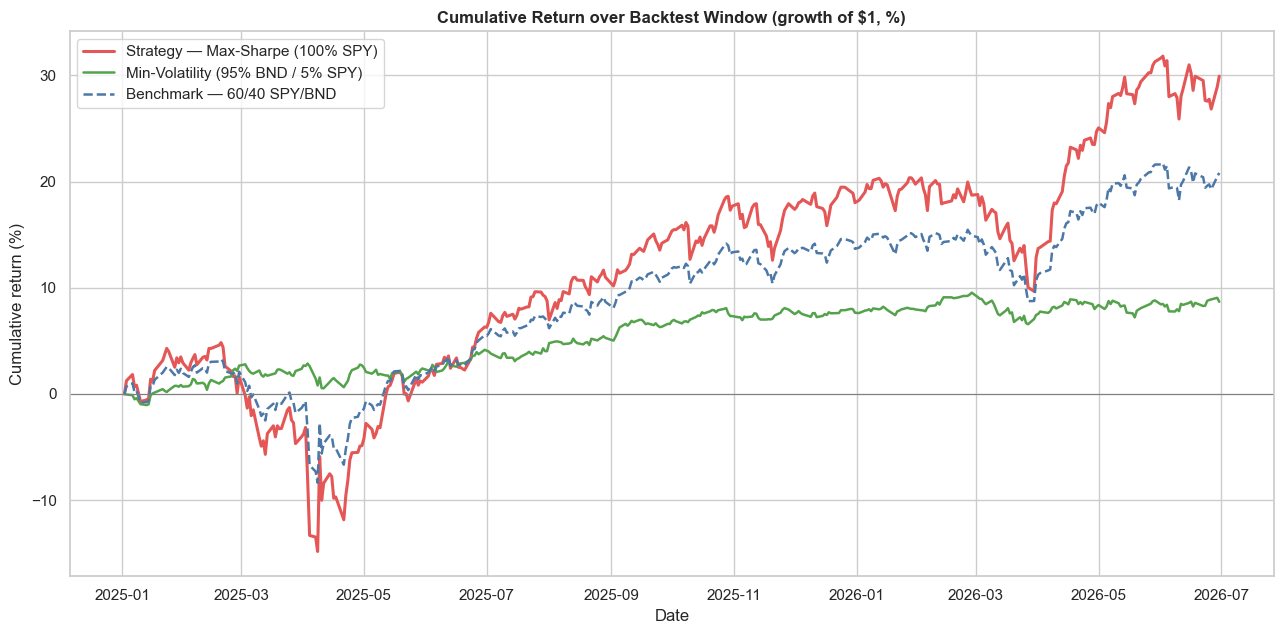

Strategy — Max-Sharpe (100% SPY)       $1.299  (+29.9%)
Min-Volatility (95% BND / 5% SPY)      $1.087  (+8.7%)
Benchmark — 60/40 SPY/BND              $1.208  (+20.8%)


In [4]:
COLORS = {"Strategy — Max-Sharpe (100% SPY)": "#E45756",
          "Min-Volatility (95% BND / 5% SPY)": "#54A24B",
          "Benchmark — 60/40 SPY/BND": "#4C78A8"}

fig, ax = plt.subplots(figsize=(13, 6.5))
for name, val in curves.items():
    style = "-" if "Benchmark" not in name else "--"
    ax.plot(val.index, (val - 1) * 100, label=name, color=COLORS[name],
            lw=2.2 if "Strategy" in name else 1.8, ls=style)
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Cumulative Return over Backtest Window (growth of $1, %)")
ax.set_ylabel("Cumulative return (%)"); ax.set_xlabel("Date"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

for name, val in curves.items():
    print(f"{name:38s} ${val.iloc[-1]:.3f}  ({(val.iloc[-1]-1)*100:+.1f}%)")

## 5 · Drawdown — depth of losses along the way

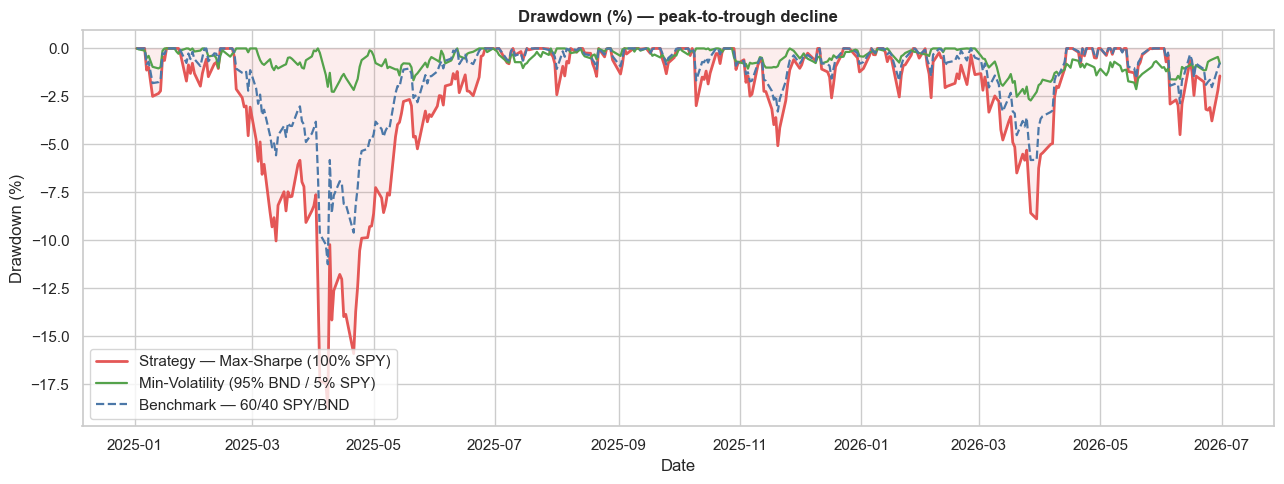

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
for name, dd in dd_curves.items():
    ax.plot(dd.index, dd * 100, label=name, color=COLORS[name],
            lw=2 if "Strategy" in name else 1.6, ls="-" if "Benchmark" not in name else "--")
ax.fill_between(dd_curves["Strategy — Max-Sharpe (100% SPY)"].index,
                dd_curves["Strategy — Max-Sharpe (100% SPY)"] * 100, 0,
                color=COLORS["Strategy — Max-Sharpe (100% SPY)"], alpha=0.10)
ax.set_title("Drawdown (%) — peak-to-trough decline")
ax.set_ylabel("Drawdown (%)"); ax.set_xlabel("Date"); ax.legend(loc="lower left")
plt.tight_layout(); plt.show()

## 6 · Does rebalancing matter here? (buy-and-hold vs. monthly)

We repeat the simulation holding the initial weights for the whole window (no rebalancing) and compare.

In [6]:
bh_rows = []
for name, w in PORTFOLIOS.items():
    perf_m, _ = performance(simulate(daily, w, rebalance="M"))
    perf_bh, _ = performance(simulate(daily, w, rebalance=None))
    bh_rows.append({"Portfolio": name,
                    "Total % (rebal)": round(perf_m["Total return %"], 2),
                    "Total % (buy&hold)": round(perf_bh["Total return %"], 2),
                    "Sharpe (rebal)": round(perf_m["Sharpe"], 2),
                    "Sharpe (buy&hold)": round(perf_bh["Sharpe"], 2)})
pd.DataFrame(bh_rows).set_index("Portfolio")

,Total % (rebal),Total % (buy&hold),Sharpe (rebal),Sharpe (buy&hold)
Portfolio,,,,
Strategy — Max-Sharpe (100% SPY),29.92,29.92,0.97,0.97
Min-Volatility (95% BND / 5% SPY),8.68,8.71,0.87,0.87
Benchmark — 60/40 SPY/BND,20.81,20.94,1.06,1.06


Over an 18-month window the two are **nearly identical** — monthly rebalancing barely changes the
outcome because weights drift only modestly on this horizon (and the 100% SPY strategy has nothing to
rebalance). Rebalancing matters more over longer horizons and with more volatile weight drift.

## 7 · Conclusion & Reflection

### Performance summary (monthly-rebalanced, 2025-01 → 2026-06)

| Portfolio | Total return | Annualized | Sharpe | Max drawdown |
|-----------|-------------:|-----------:|-------:|-------------:|
| **Strategy — Max-Sharpe (100% SPY)** | **+29.9%** | **19.4%** | 0.97 | **−18.8%** |
| Benchmark — 60/40 SPY/BND | +20.8% | 13.7% | **1.06** | −11.3% |
| Min-Volatility (95% BND) | +8.7% | 5.8% | 0.87 | −2.7% |

### Did the strategy outperform the benchmark?

**Yes on raw return, but no on risk-adjusted return — and this is the key insight.** The recommended
100%-SPY strategy earned **+29.9%** vs. the benchmark's **+20.8%**, a healthy ~9-point edge in absolute
terms. But it did so by taking materially more risk: its volatility (17.9%) and **maximum drawdown
(−18.8%)** were both far larger than the diversified benchmark's (11.0% and −11.3%). On a **risk-adjusted
basis the benchmark actually won**, posting a higher Sharpe ratio (**1.06 vs. 0.97**). In other words, the
60/40 blend delivered more return *per unit of risk* — its 40% bond sleeve cushioned the sharp early-2025
equity drawdown that the all-equity strategy took on the chin.

### What does this suggest about the model-driven approach?

The backtest **validates the process more than the specific portfolio.** The forecasting pipeline
correctly refused to over-bet on Tesla (Task 4), and the resulting equity-tilted strategy did capture the
strong 2025–2026 bull market. But the exercise also confirms the deeper lesson of the whole project:
because prices are near-random-walk (Tasks 1–3), the model has **no reliable directional edge**, so the
"strategy" reduced to a concentrated long-equity position that outperformed only because equities happened
to rise. When markets fell it had no protection. The benchmark's superior Sharpe shows that **simple
diversification remains a hard-to-beat baseline** — a sobering, honest result fully consistent with the
Efficient Market Hypothesis.

### Limitations of this backtest

- **Single, favorable regime.** One 18-month window in a rising market is not statistically
  significant; a bear market would likely favor the diversified benchmark decisively. No walk-forward /
  multiple windows were tested.
- **Corner-solution strategy.** The recommended portfolio collapsed to a single asset (100% SPY), so this
  is really "all equities vs. 60/40" — it does not exercise TSLA or dynamic reallocation.
- **Static targets, no forecast updating.** Weights were fixed from a single Task 4 optimization; a true
  strategy would re-forecast and re-optimize periodically.
- **Idealized frictions.** No transaction costs, taxes, bid-ask spreads, or slippage on rebalancing;
  dividends are handled only via adjusted-close prices.
- **Look-ahead-free but hindsight-shaped inputs.** Expected returns/covariance used history that ends just
  before the window; results are sensitive to that estimation, as Task 4's sensitivity analysis showed.

> **Bottom line:** the model-driven strategy beat the benchmark on return but not on risk-adjusted return
> or drawdown. That argues for **keeping the diversified benchmark's discipline** — the most defensible
> real-world choice is a diversified, periodically-rebalanced portfolio (closer to the 60/40 or the
> Sharpe-optimal frontier *with* diversification constraints), not a concentrated bet, and to re-validate
> across multiple market regimes before trusting it with capital.
